In [27]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
 
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)


# 1. LOAD

In [28]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders    = pd.read_csv("olist_orders_dataset.csv", parse_dates=[
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"])
payments  = pd.read_csv("olist_order_payments_dataset.csv")
items     = pd.read_csv("olist_order_items_dataset.csv", parse_dates=["shipping_limit_date"])
sellers   = pd.read_csv("olist_sellers_dataset.csv")
 
print("\nRow counts:")
for name, df in [("customers", customers), ("orders", orders),
                  ("payments", payments), ("items", items), ("sellers", sellers)]:
    print(f"  {name}: {df.shape}  columns: {df.columns.tolist()}")


Row counts:
  customers: (99441, 5)  columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
  orders: (99441, 8)  columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
  payments: (103886, 5)  columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
  items: (112650, 7)  columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
  sellers: (3095, 4)  columns: ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']


# 2. JOIN EVERYTHING INTO ONE MASTER TABLE

In [30]:
# Aggregate payments to one row per order (an order can have multiple payment rows,
# e.g. voucher + credit card split)
pay_agg = payments.groupby("order_id").agg(
    payment_value_total=("payment_value", "sum"),
    payment_installments_max=("payment_installments", "max"),
    n_payment_methods=("payment_type", "nunique"),
    payment_type_primary=("payment_type", lambda x: x.value_counts().idxmax())
).reset_index()
 
# Items joined with sellers (item-level granularity, one row per product in an order)
items_sellers = items.merge(sellers, on="seller_id", how="left")
 
# Order-level item aggregation (price, freight, number of items/sellers per order)
item_agg = items_sellers.groupby("order_id").agg(
    items_price_total=("price", "sum"),
    freight_total=("freight_value", "sum"),
    n_items=("order_item_id", "count"),
    n_distinct_sellers=("seller_id", "nunique"),
    n_distinct_products=("product_id", "nunique")
).reset_index()
 
# Master table: 1 row per order
master = (orders
          .merge(customers, on="customer_id", how="left")
          .merge(item_agg, on="order_id", how="left")
          .merge(pay_agg, on="order_id", how="left"))
 
# Derived fields
master["delivery_days"] = (master["order_delivered_customer_date"]
                            - master["order_purchase_timestamp"]).dt.days
master["estimated_days"] = (master["order_estimated_delivery_date"]
                             - master["order_purchase_timestamp"]).dt.days
master["delivery_delta_days"] = (master["order_delivered_customer_date"]
                                  - master["order_estimated_delivery_date"]).dt.days
master["is_late"] = master["delivery_delta_days"] > 0
master["order_month"] = master["order_purchase_timestamp"].dt.to_period("M").astype(str)
master["freight_ratio"] = master["freight_total"] / master["items_price_total"]
 
print("\nMaster table shape:", master.shape)
master.to_csv("master_orders.csv", index=False)
 
# Full line-item level table too (order x product x seller x customer), useful for seller/product cuts
full_lines = (items_sellers
              .merge(orders, on="order_id", how="left")
              .merge(customers, on="customer_id", how="left")
              .merge(pay_agg, on="order_id", how="left"))
full_lines.to_csv("full_line_items.csv", index=False)
print("Full line-item table shape:", full_lines.shape)


Master table shape: (99441, 27)
Full line-item table shape: (112650, 25)


# 3. KEY METRICS

In [31]:
delivered = master[master.order_status == "delivered"].copy()
 
print("\n--- Overall ---")
print("Total orders:", len(master))
print("Delivered orders:", len(delivered))
print("Order status breakdown:\n", master.order_status.value_counts())
print("\nAvg order value (items):", round(delivered.items_price_total.mean(), 2))
print("Avg freight:", round(delivered.freight_total.mean(), 2))
print("Avg freight ratio:", round(delivered.freight_ratio.mean(), 3))
print("Avg delivery days:", round(delivered.delivery_days.mean(), 1))
print("% late deliveries:", round(delivered.is_late.mean() * 100, 1))
 
# Revenue trend
rev_month = delivered.groupby("order_month")["payment_value_total"].sum().reset_index()
 
# State-level (customer)
state_perf = delivered.groupby("customer_state").agg(
    orders=("order_id", "count"),
    revenue=("payment_value_total", "sum"),
    avg_delivery_days=("delivery_days", "mean"),
    late_rate=("is_late", "mean")
).sort_values("revenue", ascending=False).reset_index()
print("\nTop 10 states by revenue:\n", state_perf.head(10))
 
# Seller performance
seller_perf = full_lines.merge(
    master[["order_id", "is_late", "delivery_days", "order_status"]],
    on="order_id", how="left", suffixes=("", "_m"))
seller_perf = seller_perf[seller_perf.order_status == "delivered"]
seller_stats = seller_perf.groupby(["seller_id", "seller_state"]).agg(
    n_orders=("order_id", "nunique"),
    revenue=("price", "sum"),
    avg_delivery_days=("delivery_days", "mean"),
    late_rate=("is_late", "mean")
).reset_index().sort_values("revenue", ascending=False)
print("\nTop 10 sellers by revenue:\n", seller_stats.head(10))
 
# Payment type behavior
pay_perf = delivered.groupby("payment_type_primary").agg(
    orders=("order_id", "count"),
    avg_value=("payment_value_total", "mean"),
    avg_installments=("payment_installments_max", "mean")
).sort_values("orders", ascending=False)
print("\nPayment type breakdown:\n", pay_perf)
 
# Correlation: freight ratio vs late delivery
corr = delivered[["freight_ratio", "delivery_days", "delivery_delta_days",
                   "payment_value_total", "n_items"]].corr()
print("\nCorrelation matrix:\n", corr.round(2))


--- Overall ---
Total orders: 99441
Delivered orders: 96478
Order status breakdown:
 order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Avg order value (items): 137.04
Avg freight: 22.79
Avg freight ratio: 0.308
Avg delivery days: 12.1
% late deliveries: 6.8

Top 10 states by revenue:
   customer_state  orders     revenue  avg_delivery_days  late_rate
0             SP   40501  5770266.19           8.298094   0.044937
1             RJ   12350  2055690.45          14.848583   0.121053
2             MG   11354  1819277.61          11.542188   0.045711
3             RS    5345   861802.40          14.819237   0.060804
4             PR    4923   781919.55          11.526711   0.040423
5             SC    3546   595208.40          14.475183   0.082064
6             BA    3256   591270.60          18.866400   0.121622
7             DF   

# 4. CHARTS

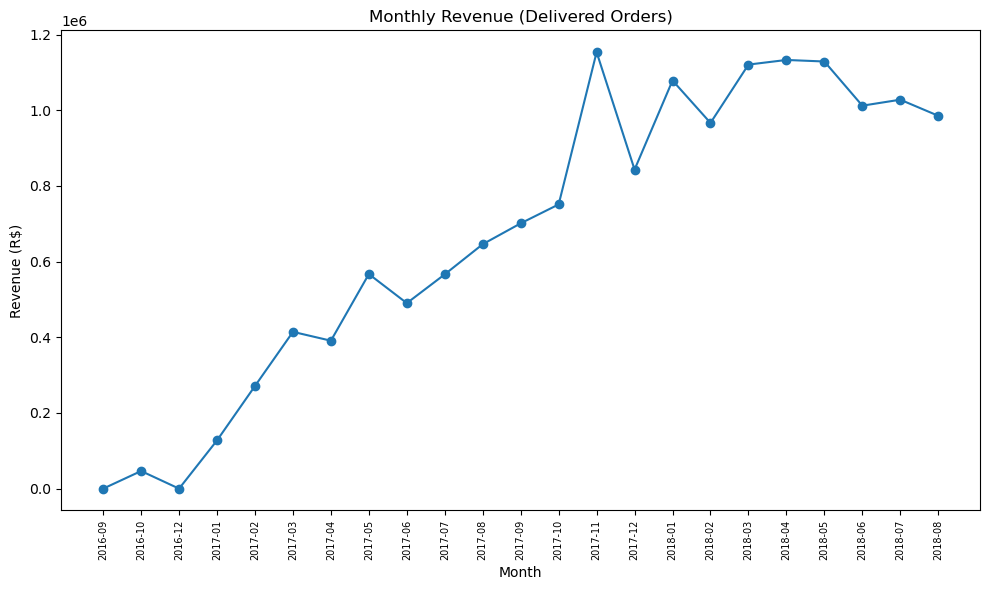

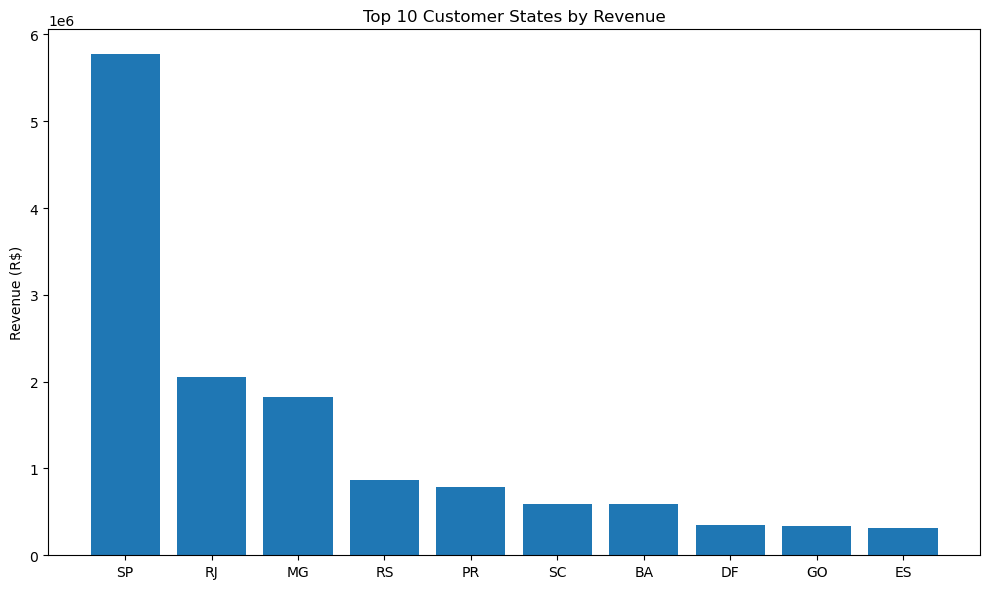

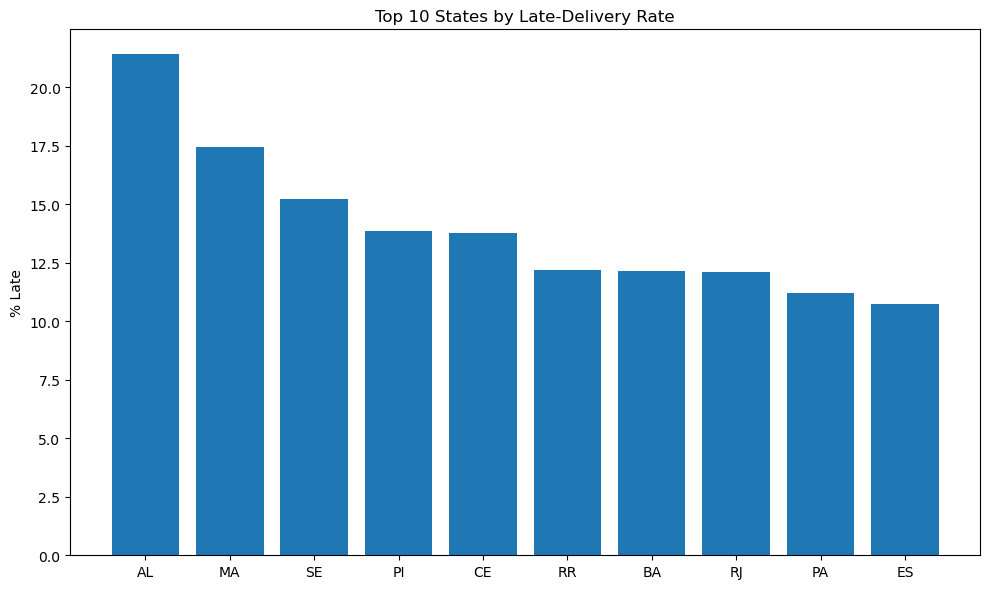

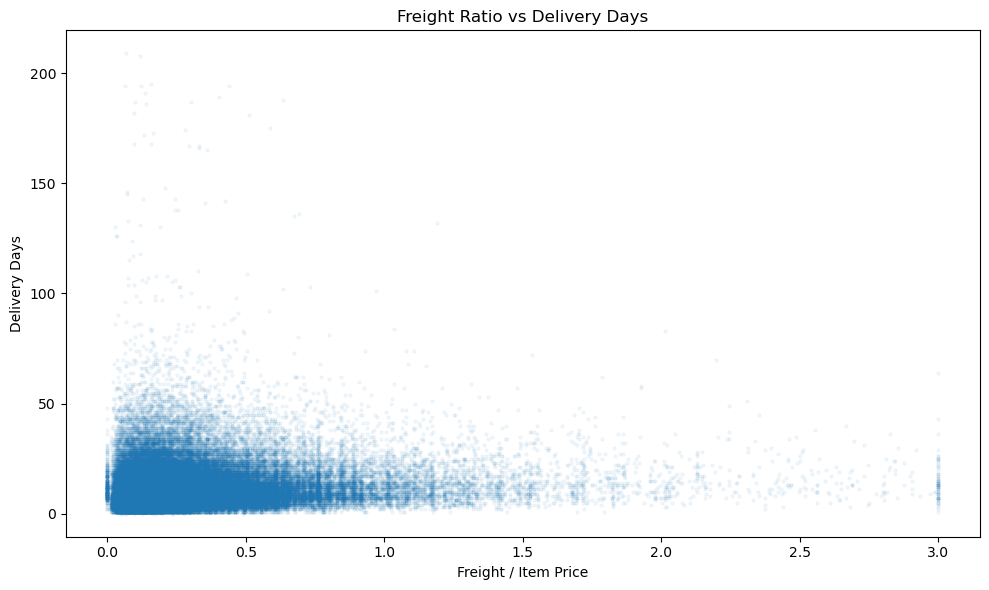


Done. master_orders.csv, full_line_items.csv and 4 PNG charts saved in: /Users/jahaankachwala/anaconda_projects/2bffcc53-c1a0-488f-9f80-fa822c8087b8


In [32]:
fig, ax = plt.subplots()
ax.plot(rev_month.order_month, rev_month.payment_value_total, marker='o')
ax.set_title("Monthly Revenue (Delivered Orders)")
ax.set_xlabel("Month"); ax.set_ylabel("Revenue (R$)")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig("monthly_revenue.png", dpi=150)
plt.show()
 
fig, ax = plt.subplots()
top10 = state_perf.head(10)
ax.bar(top10.customer_state, top10.revenue)
ax.set_title("Top 10 Customer States by Revenue")
ax.set_ylabel("Revenue (R$)")
plt.tight_layout()
plt.savefig("top_states_revenue.png", dpi=150)
plt.show()
 
fig, ax = plt.subplots()
worst10 = state_perf.sort_values("late_rate", ascending=False).head(10)
ax.bar(worst10.customer_state, worst10.late_rate * 100)
ax.set_title("Top 10 States by Late-Delivery Rate")
ax.set_ylabel("% Late")
plt.tight_layout()
plt.savefig("late_rate_by_state.png", dpi=150)
plt.show()
 
fig, ax = plt.subplots()
ax.scatter(delivered.freight_ratio.clip(upper=3), delivered.delivery_days, alpha=0.05, s=5)
ax.set_title("Freight Ratio vs Delivery Days")
ax.set_xlabel("Freight / Item Price"); ax.set_ylabel("Delivery Days")
plt.tight_layout()
plt.savefig("freight_vs_delivery.png", dpi=150)
plt.show()
 
print("\nDone. master_orders.csv, full_line_items.csv and 4 PNG charts saved in:", os.getcwd())
 